#IMPORTANT POINT 1
You can't modify this notebook. For this reason, *you need to copy the notebook to your drive. To this end, please go to File->Save a copy in Drive*.

You can make a special folder for the course in your drive. Then, use that copied version.

#IMPORTANT POINT 2
Colab grants us access to GPUs, which makes ANN training much faster. However, after a few hours, access is revoked and we have to wait. For this session, we will not train huge networks, so do not worry if you get a message saying that your GPU hours have been used up. You'll get new GPU hours after a little while.

---

#Week 1: Building blocks of ANNs
Author: Adrien Doerig

\
In this notebook, we familiarise ourselves with the basic building blocks of Artificial Neural Networks (ANNs), focussing on visual models.

We will be working with a python library called [PyTorch](https://pytorch.org/) that is designed to facilitate the creation of ANNs, and allows us to easily use GPUs to speed up ANN training and inference.

---

###Import python packages required for this notebook

As you know, Python works with packages. We need to import the ones that we are going to use. For example, pytorch is a package.

Don't worry about what the different packages do for now. We'll familiarize ourselves with them as we go.

***You need to run this cell for the rest of the notebook to work!***


In [2]:
import torch                              # <- PyTorch
from torch.utils.data import DataLoader
from torch import nn
import torchvision                        # Torch stuff for Computer vision
from torchvision import transforms

import os
import matplotlib.pyplot as plt           # Plotting library
import numpy as np                        # Mathy functions on CPU
from tqdm.notebook import tqdm            # Library to make progress bars

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


##ANN building blocks

As discussed in class, we will consider three main building blocks of ANNs:

- Datasets: the data used to train our ANNs
- Architecture: which units in our ANNs have a connection
- Objective: what the network is trained to do

In this first assignment, we will cover each of these briefly.

We start with some simple code to get a dataset, create a network, and train it on object classification. This code is all pre-written, you just need to understand what is going on to familiarize yourself with the relevant concepts.

After that, there are a couple of exercises for you to complete.

>**<font color='red'>Important note:</font>** We will cover each of these building blocks in detail in the coming weeks. The idea for today is to get acquainted with them on a superficial level, not to understand these in detail. Therefore, try to get a feel for the general framework, but don't worry if some details are not crystal clear.

>**<font color='red'>I repeat:</font>**  You should understand **in principle** what is going on. The idea is to expose you to a lot of code so you start to get a feeling for how things go. *You do not need to be able to code this from scratch.* In general, coding in the days of the internet and AI assistants is more about knowing principles, and knowing where to look than about knowing how to code everything from scratch.

##ANN building block 1: Dataset

ANNs need to be trained on data. We will start by using **<font color='red'>MNIST</font>**, a simple and small dataset consisting of images of numbers from 0-9 with associated labels. This dataset is historically important in machine learning, and can be easily downloaded directly from pytorch (this is not always the case for other less widely-used datasets).

As we will see in detail in week 3, there are two main classes for dataset handling in PyTorch:

- `Dataset`: The PyTorch `Dataset` class stores the samples and their corresponding labels. We get a `Dataset` instance when we download MNIST.
- `Dataloader`: The PyTorch `DataLoader` class enables easy and efficient access to batches of the data samples.

>*NOTE:* ANNs process several inputs at once. This is called a "batch". For example, a batch_size = 64 means that we feed 64 images in parallel to the network.

As we want to use this dataset for training ANNs, we will transform the images into pytorch **<font color='red'>tensors</font>**. Tensors are the kind of object that pytorch uses to build and train ANNs. In short, they store all the information needed for backpropagation during training, and for easy use with GPUs to speed up training and inference.

Transforming into tensors can easily be done by specifying a pytorch 'transform' object. Again, don't hesitate to search online for the other available transforms.

>*NOTE:* The ToTensor() transform also formats the image to be compatible with pytorch. This includes:
- converting to the torch.tensor type
- permuting dimensions to get [rgb_channels, height, width], as expected by pytorch
- scaling pixel values from [0,255] ints to [0,1] floats. This is because the larger values may cause numerical instability.

In [3]:
# Parameters
batch_size = 64

# Transform: convert images to pytorch tensors (cf. description above)
# Note: as we will see, we can add other transforms here for more advanced
# data processing
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download MNIST dataset train set, specify transforms
mnist_train_dataset = torchvision.datasets.MNIST(root='../data', # where to download
                                                 train=True, # get train set
                                                 transform=transform, # which transforms to apply
                                                 download=True)

# Create a dataloader, specify batch size, shuffle order
mnist_train_loader = DataLoader(mnist_train_dataset,
                                batch_size=batch_size,
                                shuffle=True)

>*Quick test:*  What is the difference between a pytorch tensor and a more standard format such as lists of numpy arrays?

---

That's it, we have our dataloader to feed MNIST images into the ANN we will create!

It is *always* good practice to plot examples from your dataloader to make sure everything looks as it should.

Here's simple code to achieve this.

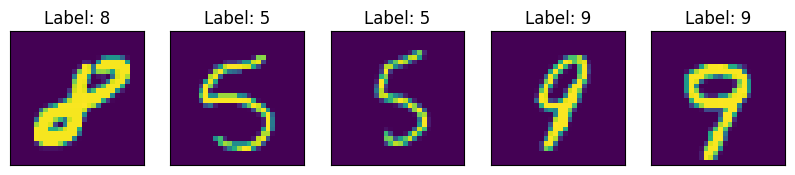

In [4]:
# This is how we get the images and labels for one single batch
# (more on this in week 3)
example_data, example_labels = next(iter(mnist_train_loader))

# plot the first 5 images and labels
fig, ax = plt.subplots(1, 5, figsize=(10,2))
for i in range(5):
    # get ith element in batch
    this_img = example_data[i]
    # as mentionned, pytorch works with images in [rgb_channels, height, width]
    # format. But matplotlib uses [height, width, rgb_channels], so we use
    # .permute() to format the image adequately.
    this_img = this_img.permute(1,2,0)
    ax[i].imshow(this_img)
    ax[i].set_title(f"Label: {example_labels[i]}")
    ax[i].set_xticks([]) # remove axis numbers for cosmetics
    ax[i].set_yticks([]) # remove axis numbers for cosmetics
plt.show()


##ANN building block 2: Network architecture


Now, let's create the architecture of our first model!

We will use a simple fully-connected network (also known as Multi-Layer Perceptron or MLP), where each unit of each layer is connected to all units in the next layer. More on ANN architectures in week 4.

The following image illustrates the architecture we will use (the numbers at the bottom indicate the number of units we will use in each layer):

![](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*SfRJNb5dOOPZYEFY5jDRqA.png)

<sub>https://miro.medium.com/v2/resize:fit:4800/format:webp/1*SfRJNb5dOOPZYEFY5jDRqA.png<sub>

In our case, we will of course use a different number of units in each layer than what is shown in this figure.
- The input layer will have 28x28=784 units (i.e., one per pixel in the input image).
- We want a single hidden layer with 64 units.
- The output layer needs 10 units (i.e., one per digit category). For example, if the 0th (or 4th) unit is the most active, the network's classifies the digit as a 0 (or a 4) -- we will cover more on output layers in week 2.

The code below shows you how to implement an ANN in pytorch. We define a class for our model, which inherits from the pytorch `nn.Module class`. This gives our network all the required machinery to be built, trained, etc.




In [5]:
# nn.Module is the base class for all neural network modules in PyTorch.
# Our SimpleMLP inherits from it.
class SimpleMLP(nn.Module):

    # __init__() method in initializes the layers and attributes of the
    # neural network when an instance is created.
    # Basically, we define all the "building blocks" we need here, and we will
    # combine them in the forward(x) function.
    def __init__(self, n_input_pixels, n_hidden):
        super().__init__()
        self.flatten = nn.Flatten()              # Converts the input image of shape (channels, heigh, width) into a flattened vector of 784 elements.
        self.hidden = nn.Linear(n_input_pixels, n_hidden) # Hidden layer
        self.relu = nn.ReLU()                    # Activation function
        self.output = nn.Linear(n_hidden, 10)    # Output layer
        self.softmax = nn.Softmax(dim=1)         # Activation function

    # forward(x) defines the forward pass of the model, specifying how
    # input x flows through the layers to produce the output.
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.softmax(x)
        return x

>#Quick test
Take some time to figure out what is going on in this code and think about how you could modify it.
1. Explain, in your own words, what the __init__() function does.
2. Explain, in your own words, what the forward() function does.
3. What would you do if you wanted to add a new layer?

For now, it is enough to get the vibe of what is going on. We'll go deeper into various architectures in week 4.

---

The previous cell *defines* the model class.

Next, we need to make an *instance* of our model, specifying the parameters we want.

>If you are confused by classes and instances, feel free to revisit the relevant programming sessions from last semester, or look online.

We tell PyTorch to put the model on the GPU, if it is available.

> Note: the `device` variable contains 'cuda' if a GPU is available, and 'cpu' if there is no GPU. We defined it at the top of this notebook, where we did the imports. If `device=='cuda'`, PyTorch puts the model on the GPU. Note that if `device=='cuda'` but you don't have access to a GPU, then you'll get an error.

In [6]:
# Create an instance of the model
mnist_model = SimpleMLP(n_input_pixels=28*28, n_hidden=64)

# Move the model to the desired device
mnist_model = mnist_model.to(device)

Now that we have our dataloader and our model instance, we can easily pass images through our model and get the corresponding network outputs.

For this:
1. We get a batch of images/labels from the dataloader as we did earlier.
2. We pass the images through the model to get the predicted labels using a single line of code: `predicted_labels = mnist_model(img_batch)`.

In [7]:
# Get a batch of images and labels from the dataloader
img_batch, label_batch = next(iter(mnist_train_loader))

# Pass the images through the model to get the predicted labels
predicted_labels = mnist_model(img_batch)

Now that we have these model responses to a batch of images, wWe can plot the images we fed to the network, along with the true labels and the network predictions.

Here is some code to do that.

>Note: The network has 10 outputs, and the idea is that if the most active output unit is the 0th output, then the netowrk prediction is 0. If the most active output unit is the 4th, the the network predictino is 4. To get the most active unit, we can use the `argmax` function.

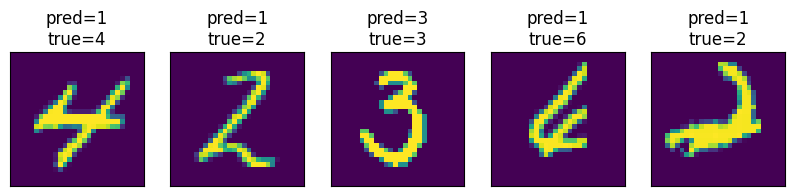

In [8]:
# Make plot with 5 images and predicted vs. true labels
fig, ax = plt.subplots(1, 5, figsize=(10,2))

for i in range(5):

  # get the ith image, and permute axes (cf. our previous dataset plotting code)
  image = img_batch[i].permute(1,2,0)
  # get true label for this image
  true_label = label_batch[i]
  # get the number predicted by the network.
  prediction = torch.argmax(predicted_labels[i])

  ax[i].imshow(image)
  ax[i].set_title(f'pred={prediction}\ntrue={true_label}')

  ax[i].set_xticks([])  # remove axis numbers
  ax[i].set_yticks([])  # remove axis numbers

##ANN building block 3: Training objective

The last building block is the network's *objective*. That is, we need to tell the network what to do. In this case, we want it to classify digits.

There are two steps (more on this next week):
1. we define the loss function to optimise.
2. we define optimizer to perform backpropagation.


In our case, here is what we will use:

**Loss function (or "criterion"):** We will use **cross-entropy**. In brief this loss function says "have a high value for the correct digit class, and a low value for all others". More on this next week.

**Optimiser:** We will use Adam, a widely used optimizer (more on this next week).

In [9]:
mnist_criterion = nn.CrossEntropyLoss()  # Standardly used for classification


mnist_optimizer = torch.optim.Adam(mnist_model.parameters(), lr=0.001)

##Training our model

We need to write a **<font color='red'>training loop</font>**, which specifies how to go through the dataloader, how to feed inputs to the network, how to compute the loss and how to update the weights.

> **<font color='red'>We will cover this next week.</font>** Feel free to skip this part for now -- you can just take for granted that this part of the code specifies how to train the model. Or look at it and see if you understand what is going on if you want!

>Note: Here, we are just using a training set. As you probably expect, moving forward we will train our networks on a training set, and then evaluate them on a held out test set.

In [10]:
def train(model, loader, criterion, optimizer, device):
    '''
    model: a pytorch model instance
    loader: a pytorch DataLoader instance
    criterion: a pytorch loss function instance
    optimizer: a pytorch optimizer instance
    device: 'cuda' or 'cpu'
    '''

    # Set the model to training mode. This helps inform layers such as Dropout
    # and BatchNorm, which are designed to behave differently during training
    # and evaluation. For instance, in training mode, dropout "kills" neurons
    # in each batch, but this is not usually done while testing.
    # In our case, we are not using any of these fancy things, but it is good to
    # get into the habit.
    model.train(True)

    # Move model to desired device (GPU/CPU)
    model.to(device)

    # The tqdm python module allows us to have a nice progress bar during
    # training. Don't be confused if it looks complicated.
    # It is just a fancy for loop. We loop over the dataloader and
    # get each item=(batch_imgs, batch_labels) each time.
    for i, item in enumerate(tqdm(loader)):

        optimizer.zero_grad()  # Set all gradients to 0

        inputs, labels = item[0], item[1]  # Pair of input and corresponding label
        inputs = inputs.to(device)         # Move to desired device (GPU/CPU)
        labels = labels.to(device)         # Move to desired device (GPU/CPU)

        outputs = model(inputs)            # Feed the input through the model
        batch_loss = criterion(outputs, labels)  # Calculate the loss

        batch_loss.backward()  # Calculate the gradient for the current loss
        optimizer.step()       # Update weights via backpropagation

        # Print the current batch loss every few batches
        if i%5==0:
          tqdm.write(f"\rBatch Loss: {batch_loss.item()}", end='')


**<font color='red'>Let's train our model!</font>** To do so, we simply use the function containing our training loop defined in the previous code cell.

In [11]:
# Train!
train(mnist_model, mnist_train_loader, mnist_criterion, mnist_optimizer, device)

  0%|          | 0/938 [00:00<?, ?it/s]

Batch Loss: 1.6296777725219727

Let's recycle our code from earlier to get network predictions. Now that we trained our network, you should get accurate predictions!

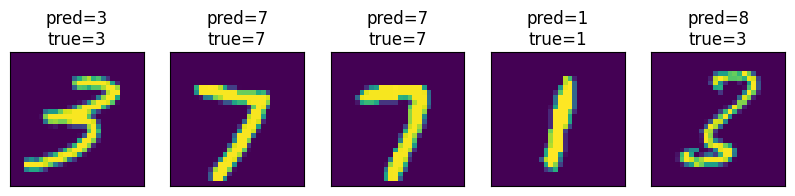

In [12]:
# Get a batch of images and labels from the dataloader
img_batch, label_batch = next(iter(mnist_train_loader))

# Pass the images through the model to get the predicted labels
predicted_labels = mnist_model(img_batch)

# Make plot with 5 images and predicted vs. true labels
fig, ax = plt.subplots(1, 5, figsize=(10,2))

for i in range(5):

  # get the ith image, and permute axes (cf. our previous dataset plotting code)
  image = img_batch[i].permute(1,2,0)
  # get true label for this image
  true_label = label_batch[i]
  # get the number predicted by the network.
  prediction = torch.argmax(predicted_labels[i])

  ax[i].imshow(image)
  ax[i].set_title(f'pred={prediction}\ntrue={true_label}')

  ax[i].set_xticks([])  # remove axis numbers
  ax[i].set_yticks([])  # remove axis numbers

Let's train our model some more to see if it improves the loss and predictions. To this end, we just call our training loop function once more.

In [13]:
# Train!
train(mnist_model, mnist_train_loader, mnist_criterion, mnist_optimizer, device)

  0%|          | 0/938 [00:00<?, ?it/s]

Batch Loss: 1.5555914640426636

Let's recycle our previous code again and plot the new network predictions. Did they improve?

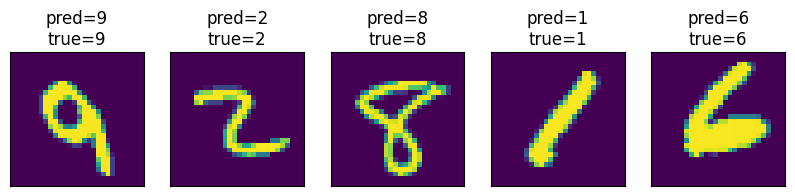

In [14]:
# Get a batch of images and labels from the dataloader
img_batch, label_batch = next(iter(mnist_train_loader))

# Pass the images through the model to get the predicted labels
predicted_labels = mnist_model(img_batch)

# Make plot with 5 images and predicted vs. true labels
fig, ax = plt.subplots(1, 5, figsize=(10,2))

for i in range(5):

  # get the ith image, and permute axes (cf. our previous dataset plotting code)
  image = img_batch[i].permute(1,2,0)
  # get true label for this image
  true_label = label_batch[i]
  # get the number predicted by the network.
  prediction = torch.argmax(predicted_labels[i])

  ax[i].imshow(image)
  ax[i].set_title(f'pred={prediction}\ntrue={true_label}')

  ax[i].set_xticks([])  # remove axis numbers
  ax[i].set_yticks([])  # remove axis numbers

##Exercise 1: Making the code better

Previously in the notebook, we re-used a code block that gets network predictions on a some images and plots them several times.

This is **bad practice**. Any code that will be re-used several times should be in a *function*.

Package all that code in a function called `plot_batch_predictions(model, loader, n_imgs)` with the model to assess, the dataloader to assess it on, and the number of images to plot as the arguments. That way, we can easily look at network predictions in the future.

You can experiment with making the plots look nicer, e.g. use a specific colormap, or arrange the images in two rows, etc.

Then, use that function to look at network predictions for 10 images.

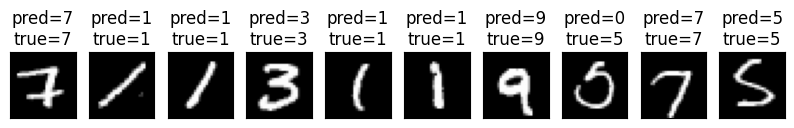

In [15]:
def plot_batch_predictions(model, loader, n_imgs):
    # Get a batch of images and labels from the dataloader
    img_batch, label_batch = next(iter(loader))

    # if we only have one color channel, use a grayscal colormap
    # otherwise, use the standard 3-channel one
    if img_batch.shape[1] == 1:
      colormap = 'gray'
    else:
      colormap = None

    # Pass the images through the model to get the predicted labels
    predicted_labels = model(img_batch)

    # Make plot with predicted vs. true labels
    # we'll have max 10 images per row
    n_rows = int(np.ceil(n_imgs/10))
    n_cols = min(10, n_imgs)
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols,n_rows*1.5))
    if n_rows == 1:
        # Need to make sure ax is 2D array even when there is a single row
        # Otherwise we get wrong indexing in the for loop below
        ax = np.expand_dims(ax, axis=0)

    for i in range(n_imgs):
        row, col = i//10, i%10
        ax[row, col].imshow(img_batch[i].permute(1,2,0), cmap=colormap)
        ax[row, col].set_title(f'pred={torch.argmax(predicted_labels[i])}\ntrue={label_batch[i]}')
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])

plot_batch_predictions(mnist_model, mnist_train_loader, 10)

We might also want to re-use the code from the *ANN building blocks 1: Dataset* section, where we plotted some images from the dataloader.

Find this code to plot a selection of images from a dataloader, and put it into a function `plot_dataset_samples(loader, n_imgs)`, similarly to what you did above.

Then plot 20 images from the dataset.

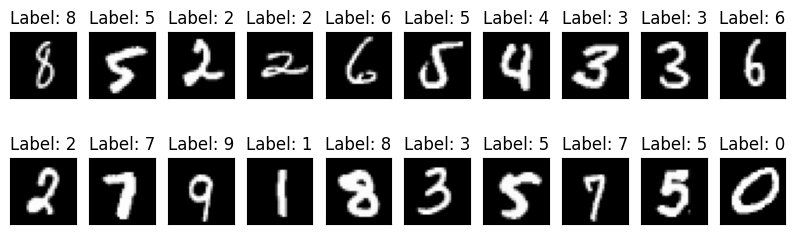

In [16]:
def plot_dataset_samples(loader, n_imgs):

    # get data from dataloader
    example_data, example_labels = next(iter(loader))

    # if we only have one color channel, use a grayscal colormap
    # otherwise, use the standard 3-channel one
    if example_data.shape[1] == 1:
      colormap = 'gray'
    else:
      colormap = None

    # Make plot with predicted vs. true labels
    # we'll have max 10 images per row
    n_rows = int(np.ceil(n_imgs/10))
    n_cols = min(10, n_imgs)
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols,n_rows*1.5))
    if n_rows == 1:
        ax = np.expand_dims(ax, axis=0)

    for i in range(n_imgs):
        this_img = example_data[i].permute(1,2,0)
        row, col = i//10, i%10
        ax[row, col].imshow(this_img, cmap=colormap)
        ax[row, col].set_title(f"Label: {example_labels[i]}")
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])
    plt.show()

plot_dataset_samples(mnist_train_loader, 20)

##Exercise 2: Use the CIFAR10 dataset

Let's apply the above steps to another dataset: [CIFAR10](https://paperswithcode.com/dataset/cifar-10). The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. The images are 32x32 pixels, with 3RGB channels.

The idea is to help you familiarize yourself with the building blocks of ANNs by making you figure out which code snippets from above to copy-paste and modify slightly.



First, we will download the [PyTorch CIFAR10 dataset](https://pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html), and create a dataloader for it.

I have prepared the structure of the code for this. Please fill it in

In [18]:
# Parameters we will use
batch_size = 64

# Transform: convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download MNIST dataset (train set)
cifar_train_dataset = torchvision.datasets.CIFAR10(root='../data', train=True, transform=transform, download=True)

# Create a dataloader
cifar_train_loader = DataLoader(cifar_train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 170M/170M [00:41<00:00, 4.11MB/s] 


Let's make sure the data look as they should. To this end, use the `plot_dataset_samples` you created in exercise 1 to plot a few images and the corresponding labels.

>Check that things look good:
- Do the images look alright?
- Do you always have the same label for images from the same class?
  - e.g. all cars should have label 1, all dogs should be label 5


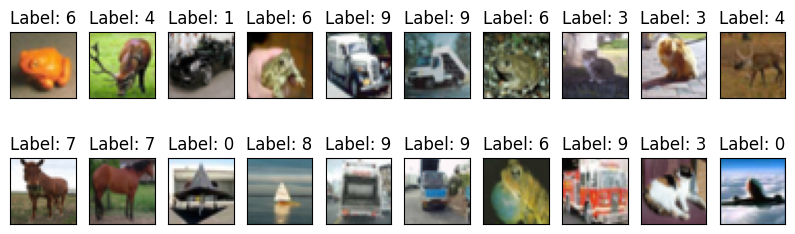

In [19]:
plot_dataset_samples(cifar_train_loader, 20)

Create a new instance of our SimpleMLP class, and move it to the current device, as we did for our mnist network instance.

>Notes:
- You don't need to redefine the model class! You only need to make a new instance.
- You will need to change the model's n_input_pixels argument. MNIST has 28x28 pixel images with 1 rgb channel (i.e., the images are grayscale), while CIFAR10 has 32x32 pixel images with 3 rgb channels. Figure out how many pixels that represents in total, and use that as the n_input_pixels argument.
- Don't forget that you can look at previous code from above, for example to see how to move the model to the desired device.

In [20]:
# Create an instance of the model
cifar_model = SimpleMLP(n_input_pixels=32*32*3, n_hidden=32)
# Move the model to the desired device
cifar_model = cifar_model.to(device)

Use the `plot_batch_predictions` function you created in exercise 1 to plot some images and the corresponding true labels and network predictions.

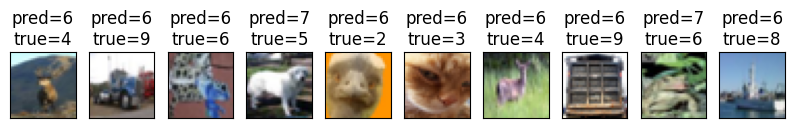

In [21]:
plot_batch_predictions(cifar_model, cifar_train_loader, 10)

Next, create the criterion and optimizer, basing yourself on the corresponding code for MNIST that we covered earlier.

In [22]:
cifar_criterion = nn.CrossEntropyLoss()  # Standardly used for classification
cifar_optimizer = torch.optim.Adam(cifar_model.parameters(), lr=0.001)

Train the network using the training loop we wrote earlier.

>Note: This should be s *single line of code*. You do not need to re-define the train function, you just need to call the one we already defined, but using the cifar model, dataloader, criterion and optimizer as arguments instead of the mnist ones.

In [23]:
# Train!
train(cifar_model, cifar_train_loader, cifar_criterion, cifar_optimizer, device)

  0%|          | 0/782 [00:00<?, ?it/s]

Batch Loss: 2.1777064800262453

Use the `plot_batch_predictions` function you created in exercise 1 to plot some images and the corresponding true labels and network predictions.

>CIFAR10 is a more difficult dataset than the MNIST we used previously. And we are using a very simple network that may not be powerful enough to solve the task perfectly. As such, we expect worse performance compared to MNIST.

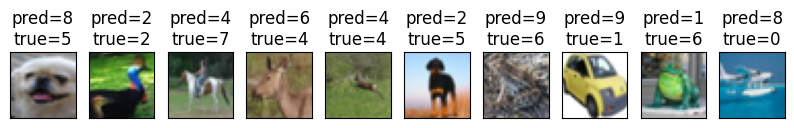

In [24]:
plot_batch_predictions(cifar_model, cifar_train_loader, 10)

Let's do some more training. Please write a for loop that calls the `train()` function 5 times, then use your `plot_batch_predictions()` function to show the results. Did accuracy improve?

>Note: Training several times in a row on a dataset is known as having several *epochs*. One epoch is one pass through the whole dataset. Hence, the for loop you will write here corresponds do doing 5 epochs of training.

  0%|          | 0/782 [00:00<?, ?it/s]

Batch Loss: 2.0928390026092537

  0%|          | 0/782 [00:00<?, ?it/s]

Batch Loss: 2.1650302410125732

  0%|          | 0/782 [00:00<?, ?it/s]

Batch Loss: 2.1849789619445866

  0%|          | 0/782 [00:00<?, ?it/s]

Batch Loss: 2.1232271194458017

  0%|          | 0/782 [00:00<?, ?it/s]

Batch Loss: 2.0509822368621826

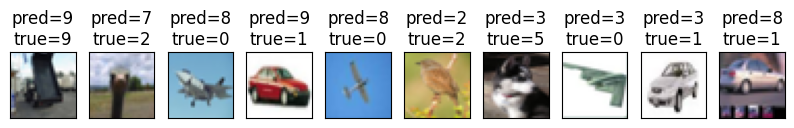

In [25]:
for epoch in range(5):
    train(cifar_model, cifar_train_loader, cifar_criterion, cifar_optimizer, device)

plot_batch_predictions(cifar_model, cifar_train_loader, 10)